<a href="https://colab.research.google.com/github/Jqueen43/Nigerian_Language_Identifier/blob/main/Nigerian_Language_Identifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Connecting hugging face to my colab notebook since I am using a gated dataset

In [ ]:
from huggingface_hub import login
from google.colab import userdata

login()

Loading the naijavoices dataset from hugging face site,reading it's metadata, renaming the language column to 'label' and checking how many text rows belongs to each Nigerian Language

In [ ]:
import pandas as pd
from huggingface_hub import hf_hub_download
metadata_path = hf_hub_download(
    repo_id="naijavoices/naijavoices-dataset-compressed",
    filename="metadata.csv" ,
    repo_type="dataset"
)

df_naija = pd.read_csv(metadata_path, sep='~', on_bad_lines='skip', low_memory=False)
df_naija = df_naija.rename(columns={'language': 'label'})

# Verify the distribution of Igbo, Yoruba and Hausa text rows
print("NaijaVoices row Counts:")
print(df_naija['label'].value_counts())

metadata.csv: reconstructing file:   0%|          |  0.00B /  282MB            

metadata.csv: downloading bytes:           |  0.00B            

NaijaVoices row Counts:
label
hausa     708599
yoruba    622156
igbo      586931
Name: count, dtype: int64


Load the English dataset from hugging face, convert it into a dataframe and display the first five rows

In [ ]:
from datasets import load_dataset

# Load the dataset from Hugging Face
ds_expanded = load_dataset('agentlans/expanded-english-sentences', split='train')

# Convert to pandas DataFrame
df_expanded = ds_expanded.to_pandas()

# Inspect the first five rows
display(df_expanded.head())

README.md:   0%|          | 0.00/1.84k [00:00<?, ?B/s]

train.jsonl.gz: reconstructing file:   0%|          |  0.00B / 3.62MB            

train.jsonl.gz: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/15048 [00:00<?, ? examples/s]

,sentence,paragraph
0,"With the development of the industry, the comp...",As the global demand for plastic films continu...
1,They are deeply worried about the possible out...,The fear is palpable as the thought of powerfu...
2,"Biometrics 52:797-810, 1996.","The 1996 article ""Biometrics 52:797-810"" alleg..."
3,The British Coroner who conducted the first Br...,"According to the given statement, it's claimed..."
4,"Nusbaum, H. C. & Pisoni, D. B. Perceptual and ...","Nusbaum, H. C. and Pisoni, D. B. explored the ..."


Take sample of 5000 from each language and combine into one dataset

In [ ]:
import pandas as pd
from huggingface_hub import hf_hub_download

# 1. Ensure df_naija is loaded and rename 'language' to 'label'
metadata_path = hf_hub_download(repo_id='naijavoices/naijavoices-dataset-compressed', filename='metadata.csv', repo_type='dataset')
df_naija = pd.read_csv(metadata_path, sep='~', on_bad_lines='skip', low_memory=False)
df_naija = df_naija.rename(columns={'language': 'label'})

# 2. Filter for Igbo, Yoruba, and Hausa and take 5,000 random samples each
languages = ['igbo', 'yoruba', 'hausa']
df_sampled_naija = df_naija[df_naija['label'].isin(languages)].groupby('label').sample(n=5000, random_state=42)
df_text_labels = df_sampled_naija[['text', 'label']].copy()

# 3. Sample 5,000 entries from the English dataset, rename 'sentence' to 'text', and add 'English' label
# Note: df_expanded was loaded in the previous cell (60cf8374)
df_expanded_sampled = df_expanded.sample(n=5000, random_state=42).copy()
df_expanded_sampled = df_expanded_sampled.rename(columns={'sentence': 'text'})
df_expanded_sampled['label'] = 'English'

# 4. Merge all into one final dataframe
df_final_combined = pd.concat([df_text_labels, df_expanded_sampled], ignore_index=True)

# Verify the counts
print('Final Combined Dataset Label Counts:')
print(df_final_combined['label'].value_counts())
display(df_final_combined.sample(5))

Final Combined Dataset Label Counts:
label
hausa      5000
igbo       5000
yoruba     5000
English    5000
Name: count, dtype: int64


,text,label,paragraph
8045,O nwere ihe dị iche na mkparịta ụka na nrụrịta...,igbo,NaN
17727,The oils used are not likely to damage the car...,English,The use of these specific oils is said to pose...
17754,There are also commissioners who are appointed...,English,"Under this system, the legislative and executi..."
11137,Lílo omi tó lọ́wọ́rọ́ láti fi wẹ̀ dára fún ara,yoruba,NaN
11749,Gbogbo Àlọ́ Yorùbá ló ní Ìjàpá nínú,yoruba,NaN


Remove unnecessary column, save the dataset as a csv file and display the first few rows

In [ ]:
if 'paragraph' in df_final_combined.columns:
    df_final_combined = df_final_combined.drop(columns=['paragraph'])

# Save to CSV
output_path = '/content/balanced_multi_language_dataset.csv'
df_final_combined.to_csv(output_path, index=False)

print(f'Dataset saved successfully to: {output_path}')
display(df_final_combined.head())

Dataset saved successfully to: /content/balanced_multi_language_dataset.csv


,text,label
0,Ana amfani da na'urar duba ciki don lura da bu...,hausa
1,Ka kawo min kaji guda ɗari bakwai da hamsin!,hausa
2,Fita yayi wankan shiga musulunci,hausa
3,Ana sayar da Kafinol a wancan kantin,hausa
4,wannan ɗan sanda kayansa sun tsufa,hausa


Import the required libraries for data manipulation, numerical and text analysis, visualization and displaying of results

In [ ]:
# Import the required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

from IPython.display import display

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('max_colwidth', 200)

# Plot style
sns.set_theme(style="whitegrid")


Inspect data to understand size, colums, data types and actual content

In [ ]:
# Inspect dataset shape and structure
print("Dataset Shape:", df_final_combined.shape)
print("\nColumns:")
print(df_final_combined.columns.tolist())

print("\nData Types:")
print(df_final_combined.dtypes)

print("\nFirst 5 records:")
display(df_final_combined.head())

Dataset Shape: (20000, 2)

Columns:
['text', 'label']

Data Types:
text     object
label    object
dtype: object

First 5 records:


,text,label
0,Ana amfani da na'urar duba ciki don lura da bugun zuciyar jariri.,hausa
1,Ka kawo min kaji guda ɗari bakwai da hamsin!,hausa
2,Fita yayi wankan shiga musulunci,hausa
3,Ana sayar da Kafinol a wancan kantin,hausa
4,wannan ɗan sanda kayansa sun tsufa,hausa


Check class distribution to see if the dataset is balanced or not.

In [ ]:
# Checking language/class distribution
print("Language Distribution:")
print(df_final_combined['label'].value_counts())

print("\nPercentage Distribution:")
print(
    df_final_combined['label']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Language Distribution:
label
hausa      5000
igbo       5000
yoruba     5000
English    5000
Name: count, dtype: int64

Percentage Distribution:
label
hausa      25.0
igbo       25.0
yoruba     25.0
English    25.0
Name: proportion, dtype: float64


Visualizing the combined dataset using a bar-chart to see hom many samples belong to each language class

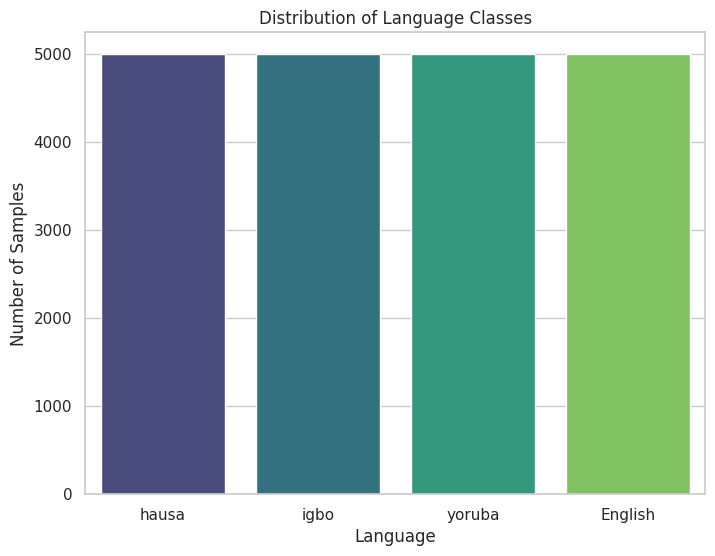

In [ ]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the class distribution
plt.figure(figsize=(8, 6))
sns.countplot(data=df_final_combined, x='label', hue='label', palette='viridis', legend=False)
plt.title('Distribution of Language Classes')
plt.xlabel('Language')
plt.ylabel('Number of Samples')
plt.show()

Checking for missing and duplicate data in the combined dataset

In [ ]:
print("Missing Values:")
print(df_final_combined.isnull().sum())

print("\nDuplicate Records:")
print(df_final_combined.duplicated().sum())

Missing Values:
text     0
label    0
dtype: int64

Duplicate Records:
140


Removing duplicates from the combined dataset and displaying the result after cleaning

In [ ]:
df_final_combined = df_final_combined.dropna(subset=["text", "label"])
df_final_combined = df_final_combined.drop_duplicates()

print("Dataset shape after cleaning:", df_final_combined.shape)




Dataset shape after cleaning: (19860, 2)


Inspect Sample texts from each language

In [ ]:
for language in df_final_combined["label"].unique():

    print("\n" + "=" * 50)
    print(f"{language.upper()} SAMPLE TEXTS")
    print("=" * 50)

    samples = (
        df_final_combined[
            df_final_combined["label"] == language
        ]["text"]
        .sample(5, random_state=42)
    )

    for i, text in enumerate(samples, 1):
        print(f"{i}. {text}")



HAUSA SAMPLE TEXTS
1. Yaro dole yaji abun da iyayen shi zasu fada mai
2. Shin sun fita yawon neman zaɓe jiya?
3. Ka wanke tukunyar idan ka gama girkin.
4. Kaka na zai ƙara aure.
5. Mai taryar baƙin da ta sauke mu ba ta kunya.

IGBO SAMPLE TEXTS
1. Mmiri nọ n’ime pọlụ a na-awụ ahụ
2. Ị zụtara ọkụkọ e ghere eghe?
3. Obika, gwa nwa gị na egwuregwu mgba amalitela.
4. Adamma, onye bụ oshiite n'ụlọ ile ọbịa, nwere ọtụtụ ngwa ishi nri.
5. Ee, mana pedalụ ịnyịnya igwe m gaara ọnụ.

YORUBA SAMPLE TEXTS
1. Fi aṣọ ìdábòbò rẹ̀ sí inú Àpámọ́wọ́ rẹ̀!
2. Mo ní kò tẹtíba fún olùkọ́ ìṣirò rẹ lánàá a máa o kọ etí ikún
3. Mo ti palẹ̀ abọ́ tí àwọn àlejò tí jẹun tán.
4. GRA jẹ́ ọ̀rọ̀ tí a máa ń lò ní Èkó àti àwọn ẹ̀ka orílẹ̀-èdè Nàìjíríà mìíràn.
5. Njé o padà je tuwo ati gbẹ̀gìrì ni alé àná?

ENGLISH SAMPLE TEXTS
1. There could be many other ways this egg could've cooked (or in actuality, the fact that it didn't cook at all) that we need to examine or at least acknowledge that they could be there.
2. 

Perform text-length analysis

In [ ]:
df_final_combined["char_count"] = df_final_combined["text"].astype(str).apply(len)

df_final_combined["word_count"] = (
    df_final_combined["text"]
    .astype(str)
    .str.split()
    .str.len()
)

display(
    df_final_combined[["label", "text", "char_count", "word_count"]]
    .head()
)



,label,text,char_count,word_count
0,hausa,Ana amfani da na'urar duba ciki don lura da bugun zuciyar jariri.,65,12
1,hausa,Ka kawo min kaji guda ɗari bakwai da hamsin!,44,9
2,hausa,Fita yayi wankan shiga musulunci,32,5
3,hausa,Ana sayar da Kafinol a wancan kantin,36,7
4,hausa,wannan ɗan sanda kayansa sun tsufa,34,6


Calculate summary statistics for text-length for each language class

In [ ]:
language_stats = (
    df_final_combined
    .groupby("label")[["char_count", "word_count"]]
    .agg(["mean", "median", "min", "max"])
)

display(language_stats)


char_count                  word_count                
               mean median min   max       mean median min  max
label                                                          
English  135.476600  123.0  20  1141  21.856000   20.0   2  190
hausa     41.430131   38.0   7   165   7.890799    7.0   1   26
igbo      42.338099   40.0  12   149   8.318768    8.0   3   26
yoruba    42.547989   39.0   7   149   8.907860    8.0   3   29

Visualize word count variation across all the four languages using a box plot

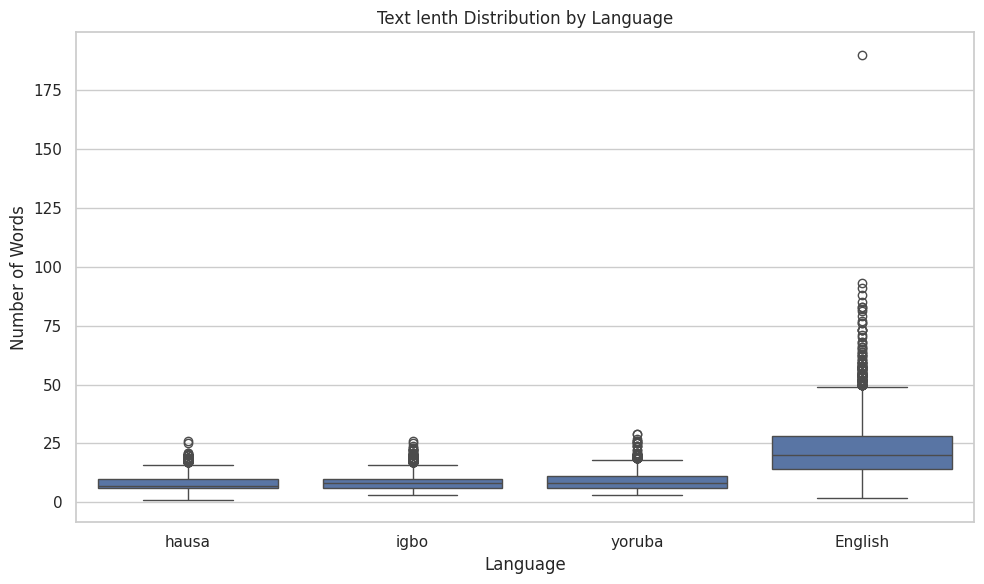

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_final_combined,
    x="label",
    y="word_count"
)
plt.title("Text lenth Distribution by Language")
plt.xlabel("Language")
plt.ylabel("Number of Words")

plt.tight_layout()
plt.show()

Count how many samples belong to each language in the label column of the final combined dataframe

In [ ]:
df_final_combined['label'].value_counts()

,count
label,
English,5000
igbo,4966
yoruba,4949
hausa,4945


Rebalancing the Class to have a harmonized class distribution

In [ ]:
min_samples = df_final_combined['label'].value_counts().min()

df_balanced = (
    df_final_combined
    .groupby('label', group_keys=False)
    .apply(lambda x: x.sample(n=min_samples, random_state=42))
    .reset_index(drop=True)
)

df_balanced['label'].value_counts()



/tmp/ipykernel_778/1108151893.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min_samples, random_state=42))


,count
label,
English,4945
hausa,4945
igbo,4945
yoruba,4945


The final dataset now contains 19,780 samples. Shuffle the rows to produce a properly mixed dataset

In [ ]:
# Shuffle the harmonized dataset to give the classifier a properly mixed dataset

df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)



Carry out character-level analysis

In [ ]:

char_sets = {}
for lang in df_balanced["label"].unique():
    text_blob = " ".join(
        df_balanced[df_balanced["label"] == lang]["text"].astype(str)
    )
    char_sets[lang] = set(text_blob.lower())

for lang, chars in char_sets.items():
    other_chars = set().union(
        *[c for l, c in char_sets.items() if l != lang]
    )

    unique_to_lang = chars - other_chars

    print(
        f"{lang}: {len(chars)} unique chars total, "
        f"{len(unique_to_lang)} not seen in other languages"
    )
    print(f" exclusive chars: {sorted(unique_to_lang)}\n")




yoruba: 96 unique chars total, 17 not seen in other languages
 exclusive chars: ['ä', 'å', 'ç', 'ê', 'î', 'õ', '÷', 'ş', 'ǹ', 'ș', '̇', '̧', '̩', '̀', '́', 'ṣ', 'ạ']

igbo: 76 unique chars total, 3 not seen in other languages
 exclusive chars: ['ē', '̄', 'ṅ']

hausa: 62 unique chars total, 6 not seen in other languages
 exclusive chars: ['`', 'ƙ', 'ƴ', 'ɓ', 'ɗ', 'ʼ']

English: 139 unique chars total, 74 not seen in other languages
 exclusive chars: ['\x19', '#', '$', '%', '&', '<', '=', '>', '@', '[', ']', '_', '|', '\x93', '\x94', '£', '§', '©', '\xad', '®', '°', '±', 'µ', 'æ', 'ë', 'û', 'ü', 'ā', 'ū', 'ά', 'α', 'β', 'δ', 'ε', 'ζ', 'ν', 'ο', 'π', 'ς', 'σ', 'τ', 'υ', 'а', 'в', 'е', 'и', 'к', 'р', 'с', 'т', 'у', 'х', 'ч', 'щ', 'ы', 'ю', 'ง', 'ท', 'บ', 'ล', 'อ', 'แ', 'ḥ', '‐', '–', '—', '†', '•', '′', '€', '℃', '™', 'ℳ', '≤']



Detect and inspect noisy characters in the english language samples

In [ ]:
# Make sure to run the previous cells that define 'df_balanced' first!
# List of some of the noisy/foreign characters found in the English text
noise_chars = ['\x19', '\x93', '\x94', '\xad', 'ά', 'α', 'β', 'δ', 'ε', 'ζ', 'ν', 'ο', 'π', 'ς', 'σ', 'τ', 'υ', 'а', 'в', 'е', 'и', 'к', 'р', 'с', 'т', 'у', 'х', 'ч', 'щ', 'ы', 'ю', 'ง', 'ท', 'บ', 'ล', 'อ', 'แ', '℃', '™', 'ℳ', '≤']

def contains_noise(text):
    return any(char in str(text) for char in noise_chars)

# Filter the English samples for these characters
if 'df_balanced' in locals() or 'df_balanced' in globals():
    noisy_samples = df_balanced[(df_balanced['label'] == 'English') & (df_balanced['text'].apply(contains_noise))]
    print(f"Found {len(noisy_samples)} English samples containing noise/foreign characters.")
    display(noisy_samples[['label', 'text']].head(15))
else:
    print("Error: 'df_balanced' is not defined. Please run the earlier cells to create this dataset.")

Found 16 English samples containing noise/foreign characters.


,label,text
1637,English,"Its not about trying to empty your mind, and as the first study cited in this article states, its about the non-judgmental awareness of sensations, feelings and state of mind."
3101,English,"We suggest that HSP70, which is expressed after either thermal or non-thermal (that is, β adrenergic stimulation) stress, protects against pancreatitis by preventing premature trypsinogen activati..."
3672,English,The participle σπουδάζοντες is of course connected with what precedes.
6988,English,"However, the PCR-corrected recrudescence rate per-protocol at day 42 for children ≤5 years was 9.4%."
8042,English,"In the word cloud, some of the most significant key words are activists (активисты), feelings (чувства) and believers (верующих)."
8132,English,"COLUMBUS, OH (June 22, 2017) ­– Children's Hunger Alliance, a statewide non-profit organization dedicated to ending childhood hunger in Ohio, today expressed its gratitude to the Ohio Senate for i..."
9700,English,Each column of ℳ describes the request for a minimum number of services on a given day.
10446,English,FzlA is conserved in α-proteobacteria and was found to be functionally critical for cell division in Caulobacter.
10497,English,How do you change а system?
13887,English,"The staffing crisis, brought on by an eight-year pay freeze and cuts in training budgets, particularly through the re­moval of nurse training bursaries, is making working conditions impossible."


Remove the noise from the english language samples

In [ ]:
# Create a mask for English samples
mask = df_balanced['label'] == 'English'

# Remove each noise character from the English text
for char in noise_chars:
    df_balanced.loc[mask, 'text'] = df_balanced.loc[mask, 'text'].astype(str).str.replace(char, '', regex=False)

# Verify the cleaning was successful
noisy_samples_after = df_balanced[(df_balanced['label'] == 'English') & (df_balanced['text'].apply(contains_noise))]
print(f"Found {len(noisy_samples_after)} English samples containing noise/foreign characters after cleaning.")

Found 0 English samples containing noise/foreign characters after cleaning.


Clean the dataset to remove unwanted characters while preserving english letters,punctuations, numbers and important characters used in hausa, yoruba and Igbo language.

In [ ]:
import re

# Regex pattern explanation:
# a-zA-Z0-9 : Basic English letters and numbers
# \s.,!?\'"\- : Spaces and basic punctuation
# \u00C0-\u017F : Latin-1 Supplement & Extended-A (common accents)
# \u0180-\u02AF : Latin Extended-B & IPA Extensions (Hausa hooked letters like ɓ, ɗ, ƙ, ƴ)
# \u1E00-\u1EFF : Latin Extended Additional (Yoruba/Igbo dotted letters like ẹ, ọ, ṣ, ị, ụ, ṅ)
# \u0300-\u036F : Combining Diacritical Marks (tone marks and subdots)
allowed_pattern = r'[^a-zA-Z0-9\s.,!?\'"\-\u00C0-\u017F\u0180-\u02AF\u1E00-\u1EFF\u0300-\u036F]'

# Create a cleaned version of the text
df_balanced['text_cleaned'] = df_balanced['text'].astype(str).str.replace(allowed_pattern, '', regex=True)

# Identify which rows were actually changed
changed_mask = df_balanced['text'] != df_balanced['text_cleaned']
print(f"Cleaned {changed_mask.sum()} rows containing unwanted characters across all languages.")

# Let's preview some of the changes before overwriting
display(df_balanced[changed_mask][['label', 'text', 'text_cleaned']].head(10))

# Overwrite original text with cleaned text and drop temporary column
df_balanced['text'] = df_balanced['text_cleaned']
df_balanced = df_balanced.drop(columns=['text_cleaned'])

Cleaned 1144 rows containing unwanted characters across all languages.


,label,text,text_cleaned
1,English,"Mission Statement|Catholic Digest connects with readers through personal stories of triumphs and struggles, joys and challenges, and also the lighter side of Catholic living.","Mission StatementCatholic Digest connects with readers through personal stories of triumphs and struggles, joys and challenges, and also the lighter side of Catholic living."
10,English,Surface Acoustic – Uses two sensors to send and receive small electric signals that the finger can interrupt to signal a touch.,Surface Acoustic Uses two sensors to send and receive small electric signals that the finger can interrupt to signal a touch.
25,English,"This is because counties where this indicator is high are also poorer than average – again, income explains most of this.","This is because counties where this indicator is high are also poorer than average again, income explains most of this."
79,English,"When it comes to your database, generally speaking, there are three kinds of failure you might eventually experience: failure across a single node, failure across multiple nodes, and complete data...","When it comes to your database, generally speaking, there are three kinds of failure you might eventually experience failure across a single node, failure across multiple nodes, and complete data ..."
96,English,"The inclusion of the United States' current North American Free Trade Agreement partners... As the world stumbles toward a summer of financial winter, one part of the American economy continues it...","The inclusion of the United States' current North American Free Trade Agreement partners... As the world stumbles toward a summer of financial winter, one part of the American economy continues it..."
101,English,"People use it during blackouts, emergencies, for safety and security, and even while playing some games; basically any time you need to see in a dark space, you'll grab your handy flashlight.","People use it during blackouts, emergencies, for safety and security, and even while playing some games basically any time you need to see in a dark space, you'll grab your handy flashlight."
115,English,"The bill would give the new regulatory agency combined oversight for the safety and soundness, as well as the housing mission, of the three housing-related government-sponsored enterprises (GSEs).","The bill would give the new regulatory agency combined oversight for the safety and soundness, as well as the housing mission, of the three housing-related government-sponsored enterprises GSEs."
157,hausa,Gobe ​​za a yi yajin aiki mara iyaka,Gobe za a yi yajin aiki mara iyaka
180,English,"When the NIV and all of the other modern versions change the passage to read: our great God and Savior, Jesus Christ, it can imply that there is more than one great God our great God and their gre...","When the NIV and all of the other modern versions change the passage to read our great God and Savior, Jesus Christ, it can imply that there is more than one great God our great God and their grea..."
181,igbo,N’ufodu ụlọakwụkwọ ọ bụ onyeisi ụlọakwụkwọ nwe ugbo di n’ụlọ ụlọakwụkwọ,Nufodu ụlọakwụkwọ ọ bụ onyeisi ụlọakwụkwọ nwe ugbo di nụlọ ụlọakwụkwọ


Check and verify that hausa diatrics are preserved

In [ ]:
# Verify that Hausa hooked letters are preserved
hausa_hooked_chars = ['ɓ', 'ɗ', 'ƙ', 'ƴ']

# Function to check for these characters
def contains_hausa_hooks(text):
    return any(char in str(text) for char in hausa_hooked_chars)

# Filter for Hausa text containing these characters
preserved_hausa = df_balanced[(df_balanced['label'].str.lower() == 'hausa') & (df_balanced['text'].apply(contains_hausa_hooks))]

print(f"Found {len(preserved_hausa)} Hausa samples that currently contain hooked letters.")
if not preserved_hausa.empty:
    display(preserved_hausa[['label', 'text']].sample(min(10, len(preserved_hausa)), random_state=42))

Found 1293 Hausa samples that currently contain hooked letters.


,label,text
5064,hausa,Nan gaba yaran kishiyoyin zasu daina faaɗa da junan su
7034,hausa,Sun cire nera dubu ɗaya a asusun banki na.
8734,hausa,Zan tuƙa motar ka zuwa wurin aiki gobe
6330,hausa,Ƙaramin yaron daga aji ɗaya na firamare yake
3842,hausa,"Kowa ya ɗauki namiji uba, zai mutu maraya."
15080,hausa,Iyalai masu uwa da yawa suna da ƙarfi saboda rungumar su.
1544,hausa,Ta saka ayabarta a cikin buhu ta ɗaure saboda ta nuna.
7804,hausa,Ba za ku gaskata ba a cikin shekaru da yawa ba su yi magana da juna ba saboda ƙasar.
7517,hausa,Mutanen ƙauyen Gobir sun iya gulma.
5868,hausa,Wasu 'yan ƙungiyar asiri sun fi ɗaukan na kusa da kai


Visualizing the character-length and word_count distribution for the four languages using a histogram

        char_len                                                           \
           count        mean        std   min   25%    50%    75%     max   
label                                                                       
english   4945.0  135.222042  72.129303  19.0  84.0  123.0  172.0  1139.0   
hausa     4945.0   41.231143  18.206624   7.0  28.0   37.0   50.0   163.0   
igbo      4945.0   42.344186  16.707217  11.0  30.0   40.0   51.0   149.0   
yoruba    4945.0   42.547219  17.936744   7.0  30.0   39.0   52.0   149.0   

        word_len                                                      
           count       mean        std  min   25%   50%   75%    max  
label                                                                 
english   4945.0  21.845298  11.456357  2.0  14.0  20.0  28.0  190.0  
hausa     4945.0   7.890394   3.290561  1.0   6.0   7.0  10.0   26.0  
igbo      4945.0   8.322548   3.208710  3.0   6.0   8.0  10.0   26.0  
yoruba    4945.0   8.907786   3.47

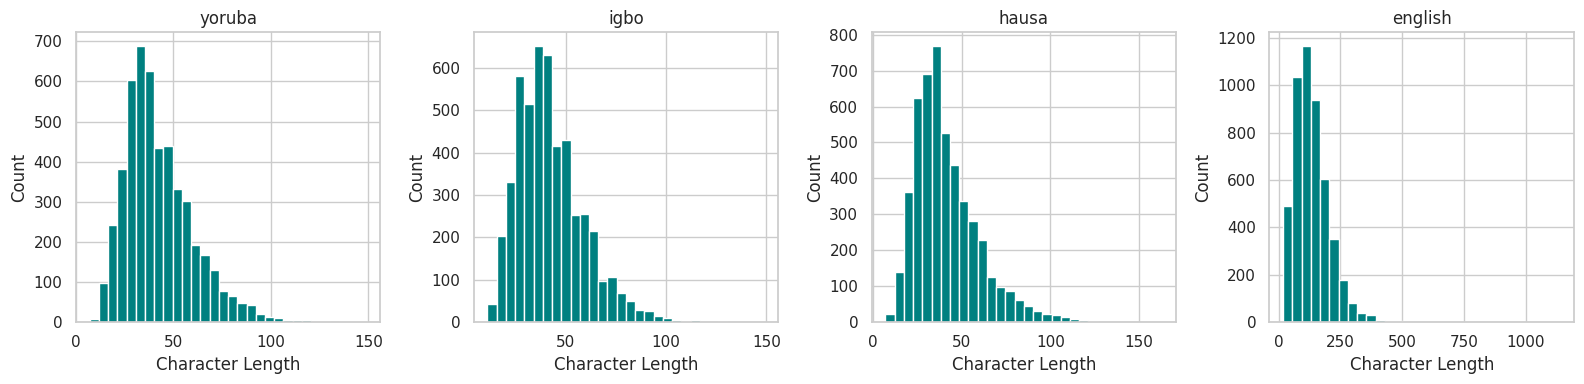

In [ ]:
df= df_balanced.copy()
df["label"] = df["label"].str.lower()
df["text"] = df["text"].str.lower()


df["char_len"] = df["text"].str.len()
df["word_len"] = df["text"].str.split().str.len()

print(df.groupby("label")[["char_len", "word_len"]].describe())

#histogram, one subplot per language
fig, axs = plt.subplots(1, len(df["label"].unique()), figsize=(16, 4))
for ax, lang in zip(axs, df["label"].unique()):
    subset = df[df["label"] == lang]
    ax.hist(subset["char_len"], bins=30, color="teal")
    ax.set_title(lang)
    ax.set_xlabel("Character Length")
    ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig("length_distribution.png")
plt.show()


Visualize the average number of words in text from each language and display result using a bar chart

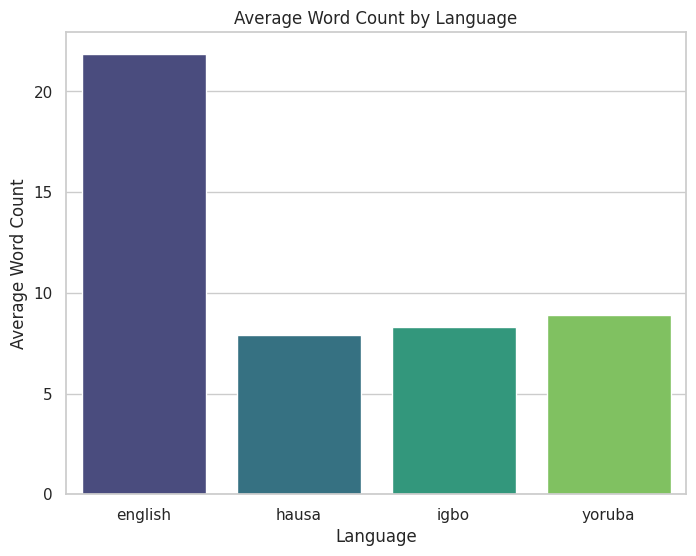

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate average word count per language
avg_word_count = df.groupby('label')['word_len'].mean().reset_index()

# Create a bar chart
plt.figure(figsize=(8, 6))
sns.barplot(data=avg_word_count, x='label', y='word_len', hue='label', palette='viridis', legend=False)
plt.title('Average Word Count by Language')
plt.xlabel('Language')
plt.ylabel('Average Word Count')
plt.show()

Check the 3 languages to observe if they contain english words

In [ ]:
import re

# 1. Investigate English Contamination in African Languages
# We check for very common English stop words as a proxy for contamination
common_english_words = ['the', 'is', 'and', 'to', 'of', 'in', 'that', 'this', 'for', 'it']
pattern = r'\b(?:' + '|'.join(common_english_words) + r')\b'

print("--- English Contamination Check (Proxy via common stop words) ---")
for lang in ['hausa', 'igbo', 'yoruba']:
    # Using the lowercased df from the previous step
    mask = (df['label'] == lang) & (df['text'].str.contains(pattern, flags=re.IGNORECASE, regex=True))
    contaminated_samples = df[mask]
    print(f"{lang.capitalize()}: {len(contaminated_samples)} samples contain common English words.")
    if len(contaminated_samples) > 0:
        display(contaminated_samples[['label', 'text']].head(2))

--- English Contamination Check (Proxy via common stop words) ---
Hausa: 155 samples contain common English words.


,label,text
104,hausa,darakta shine yake nuna yadda fim in zai gudana
431,hausa,an kashe talabijan in


Igbo: 8 samples contain common English words.


,label,text
857,igbo,onyoonyo ọsụọfịa in lọndọn sokwa n'ihe m ga-ekiri.
1651,igbo,ee the wheelbarrow dị n'ụlọ


Yoruba: 142 samples contain common English words.


,label,text
93,yoruba,awọn aila-nfani ti ṣiṣe fiimu le pẹlu awọn idiyele iṣelọpọ giga ati idije to lagbara
265,yoruba,"rárá, ó kú sínú ìjàmbá mọ́tò."


Carry out orthographic character verification for the 3 Nigerian language dataset

In [ ]:
# 2. Verify Orthographic Characters
print("--- Orthographic Character Verification ---")
# Mapping specific characters expected in each language's orthography
orthography = {
    'hausa': ['ɓ', 'ɗ', 'ƙ', 'ƴ'],
    'yoruba': ['ẹ', 'ọ', 'ṣ', 'á', 'é', 'í', 'ó', 'ú', 'à', 'è', 'ì', 'ò', 'ù'],
    'igbo': ['ị', 'ụ', 'ṅ', 'ọ', 'ẹ']
}

for lang, chars in orthography.items():
    # Combine characters into a regex character class
    char_pattern = r'[' + ''.join(chars) + ']'
    mask = (df['label'] == lang) & (df['text'].str.contains(char_pattern, regex=True))
    total_lang = len(df[df['label'] == lang])
    print(f"{lang.capitalize()}: {mask.sum()} out of {total_lang} samples contain specific orthographic characters.")

--- Orthographic Character Verification ---
Hausa: 706 out of 4945 samples contain specific orthographic characters.
Yoruba: 4753 out of 4945 samples contain specific orthographic characters.
Igbo: 4581 out of 4945 samples contain specific orthographic characters.


check for duplicates and carry out text-analysis on the dataset

In [ ]:
# 3. Duplicate and Text-Length Analysis
print("--- Duplicate Analysis ---")
# Check for exact duplicate texts
duplicates = df.duplicated(subset=['text']).sum()
print(f"Total exact duplicate texts in the dataset: {duplicates}")

print("\n--- Text-Length Extremes (Word Count) ---")
# Summarize the minimum and maximum word lengths per language
extremes = df.groupby('label')['word_len'].agg(['min', 'max', 'mean']).round(2)
display(extremes)

--- Duplicate Analysis ---
Total exact duplicate texts in the dataset: 0

--- Text-Length Extremes (Word Count) ---


,min,max,mean
label,,,
english,2,190,21.85
hausa,1,26,7.89
igbo,3,26,8.32
yoruba,3,29,8.91


Save the balanced dataset

In [ ]:
output_csv_path = '/content/final_cleaned_dataset.csv'

# Export the balanced and cleaned dataset to CSV
df_balanced.to_csv(output_csv_path, index=False)

print(f"Final balanced dataset successfully exported to: {output_csv_path}")

Final balanced dataset successfully exported to: /content/final_cleaned_dataset.csv


Split the dataset 80/20 and display both the train and test class distribution

In [ ]:
from sklearn.model_selection import train_test_split

# Perform an 80/20 stratified split on the balanced dataset
train_df, test_df = train_test_split(
    df_balanced,
    test_size=0.2,
    stratify=df_balanced['label'],
    random_state=42
)

# Verify the dimensions of the splits
print("Train set shape:", train_df.shape)
print("Test set shape:", test_df.shape)

# Verify that the class distribution remains balanced (stratification check)
print("\n--- Train Set Class Distribution ---")
print(train_df['label'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

print("\n--- Test Set Class Distribution ---")
print(test_df['label'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

Train set shape: (15824, 4)
Test set shape: (3956, 4)

--- Train Set Class Distribution ---
label
igbo       25.0%
English    25.0%
yoruba     25.0%
hausa      25.0%
Name: proportion, dtype: object

--- Test Set Class Distribution ---
label
hausa      25.0%
igbo       25.0%
English    25.0%
yoruba     25.0%
Name: proportion, dtype: object


Visualize the train/test distribution of the dataset using a bar chart

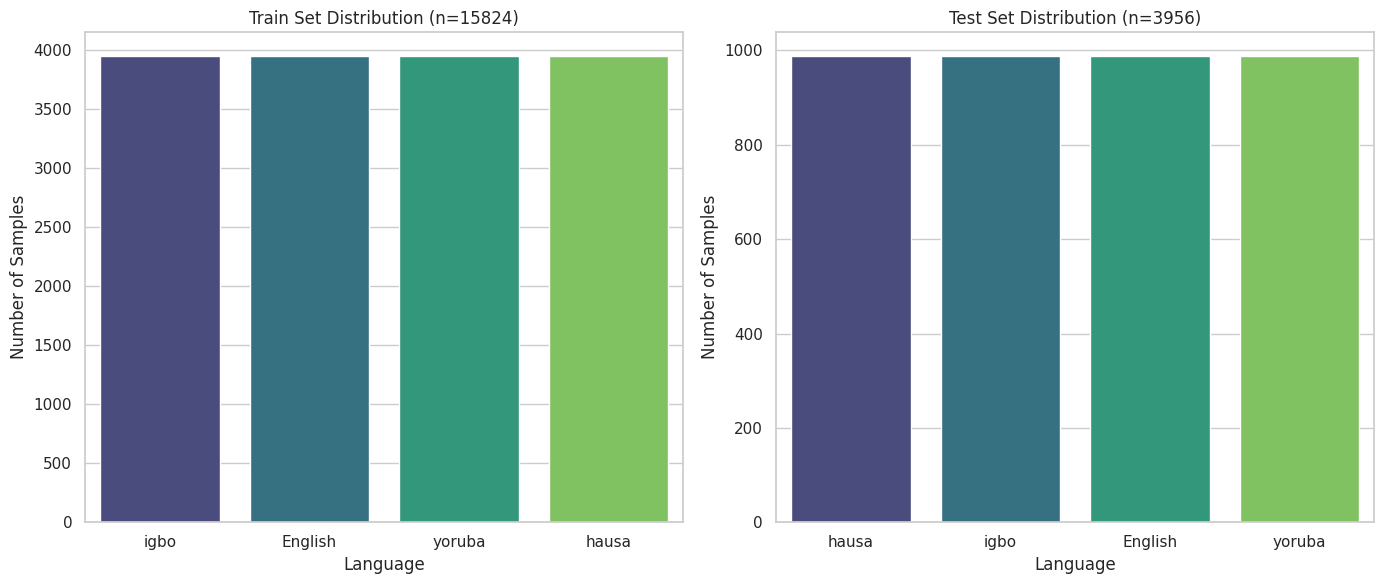

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot for Train Set
sns.countplot(data=train_df, x='label', hue='label', palette='viridis', ax=axes[0], legend=False)
axes[0].set_title(f'Train Set Distribution (n={len(train_df)})')
axes[0].set_xlabel('Language')
axes[0].set_ylabel('Number of Samples')

# Plot for Test Set
sns.countplot(data=test_df, x='label', hue='label', palette='viridis', ax=axes[1], legend=False)
axes[1].set_title(f'Test Set Distribution (n={len(test_df)})')
axes[1].set_xlabel('Language')
axes[1].set_ylabel('Number of Samples')

plt.tight_layout()
plt.show()

Convert text data into numerical TF-IDF features using character n-grams

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize a TF-IDF Vectorizer with character n-grams
# 'char_wb' creates character n-grams only from text inside word boundaries
tfidf_vectorizer = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 4), max_features=10000)

# Fit the vectorizer on the training data and transform both train and test sets
print("Fitting TF-IDF vectorizer on training data...")
X_train_tfidf = tfidf_vectorizer.fit_transform(train_df['text'])
X_test_tfidf = tfidf_vectorizer.transform(test_df['text'])

print("TF-IDF features built successfully!")
print("Train features shape:", X_train_tfidf.shape)
print("Test features shape:", X_test_tfidf.shape)


Fitting TF-IDF vectorizer on training data...
TF-IDF features built successfully!
Train features shape: (15824, 10000)
Test features shape: (3956, 10000)


Train a baseline model Naive Bayes Classifier using the train dataset. Display the accuracy score

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

# Initialize the Multinomial Naive Bayes classifier
nb_classifier = MultinomialNB()

# Train the model
print("Training Multinomial Naive Bayes model...")
nb_classifier.fit(X_train_tfidf, train_df['label'])

# Make predictions on the test set
print("Predicting on test set...")
y_pred_nb = nb_classifier.predict(X_test_tfidf)

# Calculate and display the accuracy
accuracy_nb = accuracy_score(test_df['label'], y_pred_nb)
print(f"\nBaseline Accuracy: {accuracy_nb * 100:.2f}%")

# Display detailed classification report
print("\nClassification Report:")
print(classification_report(test_df['label'], y_pred_nb))


Training Multinomial Naive Bayes model...
Predicting on test set...

Baseline Accuracy: 99.44%

Classification Report:
              precision    recall  f1-score   support

     English       0.99      1.00      1.00       989
       hausa       0.99      1.00      0.99       989
        igbo       1.00      0.99      0.99       989
      yoruba       1.00      0.99      0.99       989

    accuracy                           0.99      3956
   macro avg       0.99      0.99      0.99      3956
weighted avg       0.99      0.99      0.99      3956



Train a Linear Regression model using the train data and display the accuracy score

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Initialize the Logistic Regression classifier
# Increased max_iter to ensure convergence with TF-IDF features
lr_classifier = LogisticRegression(max_iter=1000)

# Train the model
print("Training Logistic Regression model...")
lr_classifier.fit(X_train_tfidf, train_df['label'])

# Make predictions on the test set
print("Predicting on test set...")
y_pred_lr = lr_classifier.predict(X_test_tfidf)

# Calculate and display the accuracy
accuracy_lr = accuracy_score(test_df['label'], y_pred_lr)
print(f"\nLogistic Regression Accuracy: {accuracy_lr * 100:.2f}%")

# Display detailed classification report
print("\nClassification Report:")
print(classification_report(test_df['label'], y_pred_lr))


Training Logistic Regression model...
Predicting on test set...

Logistic Regression Accuracy: 99.54%

Classification Report:
              precision    recall  f1-score   support

     English       0.99      1.00      1.00       989
       hausa       0.99      0.99      0.99       989
        igbo       1.00      0.99      1.00       989
      yoruba       1.00      0.99      1.00       989

    accuracy                           1.00      3956
   macro avg       1.00      1.00      1.00      3956
weighted avg       1.00      1.00      1.00      3956



Using the vectorizer, check for the top 10 important characters per language and display the result

In [ ]:
import pandas as pd
import numpy as np

# Get the feature names (character n-grams) from the vectorizer
feature_names = tfidf_vectorizer.get_feature_names_out()

# Dictionary to store the top features for each language
top_features = {}

# Iterate over each class (language) in the logistic regression model
for i, language in enumerate(lr_classifier.classes_):
    # Get the coefficients for the current class
    coefs = lr_classifier.coef_[i]

    # Get the indices of the top 10 highest coefficients
    top_indices = np.argsort(coefs)[-10:][::-1]

    # Map indices to the actual character n-grams
    top_ngrams = feature_names[top_indices]
    top_features[language] = top_ngrams

# Create a DataFrame for neat display
top_features_df = pd.DataFrame(top_features)
top_features_df.index = [f"Rank {i+1}" for i in range(10)]

print("Top 10 Most Important Character N-grams by Language:")
display(top_features_df)


Top 10 Most Important Character N-grams by Language:


,English,hausa,igbo,yoruba
Rank 1,s,a,ụ,í
Rank 2,th,ya,ị,́
Rank 3,t,da,e,ni
Rank 4,d,an,n,ẹ
Rank 5,th,sa,m,l
Rank 6,he,ka,a-,ni
Rank 7,the,wa,m,á
Rank 8,y,da,ọ,ó
Rank 9,er,n,ny,ì
Rank 10,the,z,ụ,é


Check for and display misclassified samples by the Logistic Regression model

In [ ]:
import pandas as pd

# Identify misclassified samples for the Logistic Regression model
misclassified_mask = test_df['label'] != y_pred_lr

# Extract the misclassified data
misclassified_df = test_df[misclassified_mask].copy()
misclassified_df['predicted_label'] = y_pred_lr[misclassified_mask]

# Reorder columns for better readability
misclassified_df = misclassified_df[['text', 'label', 'predicted_label']]
misclassified_df = misclassified_df.rename(columns={'label': 'true_label'})

print(f"Total Misclassified Samples (Logistic Regression): {len(misclassified_df)} out of {len(test_df)}")

# Display all misclassified samples
display(misclassified_df)

Total Misclassified Samples (Logistic Regression): 18 out of 3956


,text,true_label,predicted_label
17459,Ya turu ya ime,igbo,hausa
1176,Moto mi baje lana,yoruba,hausa
16120,this is not the type of screwdriver I need for the work,hausa,English
2480,"Jigawa stetii n asụ mangawa,badawa nakwa ngizomawa.",igbo,hausa
10892,Maa jo elubo to ba ya,yoruba,hausa
12901,Mo da Asoebi re pada lana,yoruba,hausa
17866,Cement na adi ka aja ma ikuọ ya ikuku.,igbo,hausa
16065,NI ƴar Nigeria ne.,hausa,yoruba
4892,Shoes will be sold at cheaper prices if the cost of leather decreases,yoruba,English
9781,It's at the car park,yoruba,English


Test the Logistic Regression model with new sentences not seen in the training dataset

In [ ]:
import pandas as pd

# Define some custom text strings to test the model
custom_texts = [
    "The quick brown dog jumps over the lazy cat.",  # English
    "Ina son in koyi yadda ake dafa abinci.",        # Hausa
    "Nne m na-esi nri ụtọ nke ukwuu.",               # Igbo
    "Báwo ni nǹkan ṣe ń lọ ní ilé ẹ̀kọ́ rẹ?",        # Yoruba
    "I am going to the market to buy some nri.",     # Mixed (English + Igbo)
    "Ba mi soro, I don't understand you.",           # Mixed (Yoruba + English)
]

# 1. Transform the text using our fitted TF-IDF character n-gram vectorizer
custom_tfidf = tfidf_vectorizer.transform(custom_texts)

# 2. Predict the language using the trained Logistic Regression model
predictions = lr_classifier.predict(custom_tfidf)

# 3. Get the prediction probabilities (confidence scores)
probabilities = lr_classifier.predict_proba(custom_tfidf)
max_probs = probabilities.max(axis=1) * 100

# Create a DataFrame to show the results neatly
results_df = pd.DataFrame({
    'Custom Text': custom_texts,
    'Predicted Language': predictions,
    'Confidence Score': [f"{p:.2f}%" for p in max_probs]
})

display(results_df)


,Custom Text,Predicted Language,Confidence Score
0,The quick brown dog jumps over the lazy cat.,English,95.08%
1,Ina son in koyi yadda ake dafa abinci.,hausa,98.42%
2,Nne m na-esi nri ụtọ nke ukwuu.,igbo,99.27%
3,Báwo ni nǹkan ṣe ń lọ ní ilé ẹ̀kọ́ rẹ?,yoruba,99.91%
4,I am going to the market to buy some nri.,English,70.19%
5,"Ba mi soro, I don't understand you.",English,52.59%


Introduce confusion matrix into the model

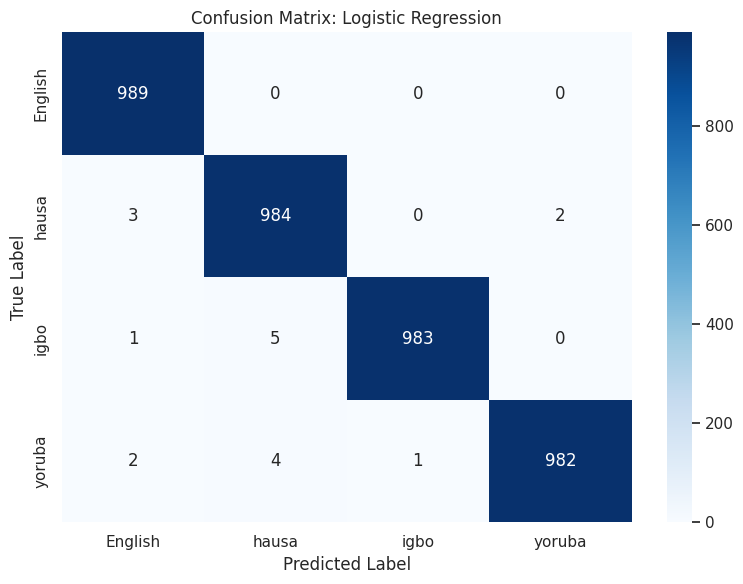

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix
cm = confusion_matrix(test_df['label'], y_pred_lr, labels=lr_classifier.classes_)

# Plot the confusion matrix using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=lr_classifier.classes_,
            yticklabels=lr_classifier.classes_)

plt.title('Confusion Matrix: Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

Train a Linear SVM model using the training dataset and display the accuracy score and classification report

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

# Initialize the Linear SVM classifier
svm_classifier = LinearSVC(random_state=42)

# Train the model
print("Training Linear SVM model...")
svm_classifier.fit(X_train_tfidf, train_df['label'])

# Make predictions on the test set
print("Predicting on test set...")
y_pred_svm = svm_classifier.predict(X_test_tfidf)

# Calculate and display the accuracy
accuracy_svm = accuracy_score(test_df['label'], y_pred_svm)
print(f"\nLinear SVM Accuracy: {accuracy_svm * 100:.2f}%")

# Display detailed classification report
print("\nClassification Report:")
print(classification_report(test_df['label'], y_pred_svm))


Training Linear SVM model...
Predicting on test set...

Linear SVM Accuracy: 99.72%

Classification Report:
              precision    recall  f1-score   support

     English       0.99      1.00      1.00       989
       hausa       1.00      1.00      1.00       989
        igbo       1.00      1.00      1.00       989
      yoruba       1.00      1.00      1.00       989

    accuracy                           1.00      3956
   macro avg       1.00      1.00      1.00      3956
weighted avg       1.00      1.00      1.00      3956



Carry out cross-validation on the Linear SVM model

Performing 5-fold cross-validation for Linear SVM...

Cross-Validation Scores (5 folds): [99.75 99.84 99.78 99.87 99.87]
Mean CV Accuracy: 99.82%
Standard Deviation: +/- 0.05%


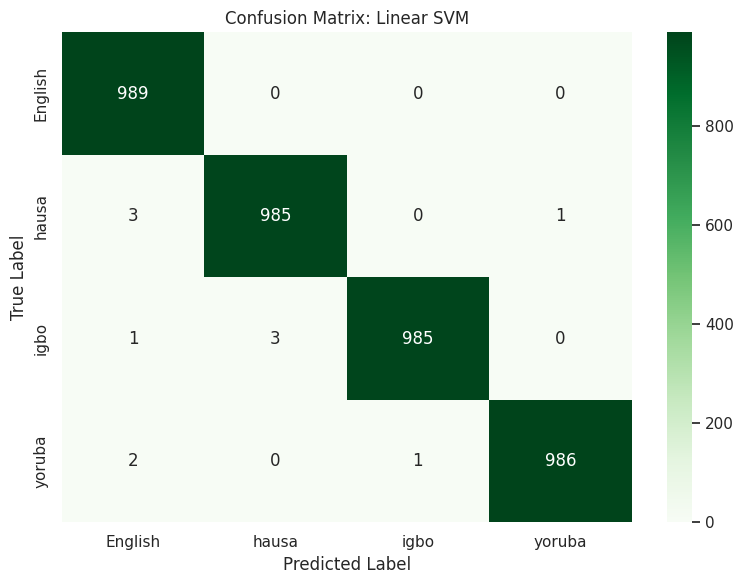

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Perform 5-fold Cross-Validation on the training data
print("Performing 5-fold cross-validation for Linear SVM...")
cv_scores = cross_val_score(svm_classifier, X_train_tfidf, train_df['label'], cv=5, n_jobs=-1)

print(f"\nCross-Validation Scores (5 folds): {np.round(cv_scores * 100, 2)}")
print(f"Mean CV Accuracy: {cv_scores.mean() * 100:.2f}%")
print(f"Standard Deviation: +/- {cv_scores.std() * 100:.2f}%")

# 2. Compute and Plot the Confusion Matrix for the Test Set
cm_svm = confusion_matrix(test_df['label'], y_pred_svm, labels=svm_classifier.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens',
            xticklabels=svm_classifier.classes_,
            yticklabels=svm_classifier.classes_)

plt.title('Confusion Matrix: Linear SVM')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

Save the Linear SVM model using joblib

In [ ]:
import joblib

# Define file paths
model_path = '/content/linear_svm_model.joblib'
vectorizer_path = '/content/tfidf_vectorizer.joblib'

# Save the Linear SVM model
joblib.dump(svm_classifier, model_path)
print(f"Model successfully saved to: {model_path}")

# Save the TF-IDF vectorizer
joblib.dump(tfidf_vectorizer, vectorizer_path)
print(f"Vectorizer successfully saved to: {vectorizer_path}")

Model successfully saved to: /content/linear_svm_model.joblib
Vectorizer successfully saved to: /content/tfidf_vectorizer.joblib


In [65]:
from google.colab import userdata
GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')

print("Token loaded successfully:", GITHUB_TOKEN is not None)

Token loaded successfully: True
